In [47]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 20)
pd.set_option("display.width", None)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
PRIORITY_THRESHOLD = 2


In [48]:
from pathlib import Path
import shutil
import kagglehub

# Download the dataset, then copy it into a project-local dataset folder.
project_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
dataset_dir = project_root / "dataset"
dataset_dir.mkdir(parents=True, exist_ok=True)

cache_path = Path(kagglehub.dataset_download("thoughtvector/customer-support-on-twitter"))

for item in cache_path.iterdir():
    destination = dataset_dir / item.name
    if item.is_dir():
        shutil.copytree(item, destination, dirs_exist_ok=True)
    else:
        shutil.copy2(item, destination)

print("Path to dataset files:", dataset_dir.resolve())

Path to dataset files: C:\Users\Kayan\OneDrive\Desktop\SE Factory\week3_project\dataset


In [49]:
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
twcs_path = project_root / "dataset" / "twcs" / "twcs.csv"

df = pd.read_csv(twcs_path)
df.head()


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so that we can further assist you. Just click â€˜Messageâ€™ at the top of your profile.,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [50]:
# Keep only inbound tweets with non-null tweet_id and text.
filtered_df = df.loc[
    df["inbound"] == True,
    ["tweet_id", "text", "response_tweet_id", "in_response_to_tweet_id"],
].dropna(subset=["tweet_id", "text"]).reset_index(drop=True)
filtered_df = filtered_df.dropna(subset=['text'])
filtered_df = filtered_df[filtered_df["text"].str.len() > 20]

def is_support_reply(t):
    t = t.lower()
    patterns = ["please dm", "we're sorry", "let us know", "contact us", "thanks for reaching"]
    return any(p in t for p in patterns)

filtered_df = filtered_df[~filtered_df["text"].apply(is_support_reply)]
filtered_df.head()


,tweet_id,text
0,2,@sprintcare and how do you propose we do that
1,3,@sprintcare I have sent several private messages and no one is responding as usual
3,8,@sprintcare is the worst customer service
4,12,@sprintcare You gonna magically change your connectivity for me and my whole family ? ðŸ¤¥ ðŸ’¯
5,16,@sprintcare Since I signed up with you....Since day 1


In [51]:
URGENT_PATTERNS = {
    "security_billing": [r"\brefund\b", r"\bcharged\b", r"\bfraud\b", r"\bhacked\b", r"\bstolen\b", r"\bunauthorized\b"],
    "access_lockout": [r"\blocked\b", r"\blocked out\b", r"\baccount locked\b", r"\bcannot login\b", r"\bcan[' ]?t login\b", r"\bcant login\b"],
    "service_failure": [r"\bnot working\b", r"\bservice down\b", r"\boutage\b", r"\bbroken\b", r"\bfailed\b", r"\berror\b", r"\bwon[' ]?t work\b", r"\bunable to\b", r"\bsession has expired\b"],
    "time_sensitive": [r"\basap\b", r"\burgent\b", r"\bimmediately\b", r"\bright now\b", r"\btoday\b", r"\bnow\b"],
    "travel_order": [r"\bflight\b", r"\bbooking\b", r"\bdelivery\b", r"\border\b", r"\breservation\b", r"\bcheck[- ]?in\b"],
    "frustration": [r"\bworst\b", r"\bridiculous\b", r"\bunacceptable\b", r"\bangry\b", r"\bdisappointed\b", r"\bunsafe\b"],
}

NON_URGENT_PATTERNS = [
    r"\bthank you\b",
    r"\bthanks\b",
    r"\bgreat service\b",
    r"\bjust wondering\b",
    r"\bfeature request\b",
]

CATEGORY_WEIGHTS = {
    "security_billing": 3,
    "access_lockout": 3,
    "service_failure": 2,
    "time_sensitive": 2,
    "travel_order": 1,
    "frustration": 1,
}

compiled_urgent_patterns = {
    category: [re.compile(pattern) for pattern in patterns]
    for category, patterns in URGENT_PATTERNS.items()
}

compiled_non_urgent_patterns = [re.compile(pattern) for pattern in NON_URGENT_PATTERNS]

def normalize_text(text):
    text = str(text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def score_priority(text):
    text = normalize_text(text)
    t = text.lower()
    score = 0

    for category, patterns in compiled_urgent_patterns.items():
        if any(pattern.search(t) for pattern in patterns):
            score += CATEGORY_WEIGHTS[category]

    if text.count("!") >= 2:
        score += 1

    alpha_count = sum(char.isalpha() for char in text)
    upper_ratio = sum(char.isupper() for char in text if char.isalpha()) / max(1, alpha_count)
    if upper_ratio > 0.3:
        score += 1

    if any(phrase in t for phrase in ["still not fixed", "again", "for hours", "for days", "no one is responding"]):
        score += 1

    if any(pattern.search(t) for pattern in compiled_non_urgent_patterns):
        score -= 2

    if any(pattern.search(t) for pattern in compiled_urgent_patterns["travel_order"]):
        if any(pattern.search(t) for pattern in compiled_urgent_patterns["time_sensitive"] + compiled_urgent_patterns["service_failure"]):
            score += 1

    return score

def label_priority(text, threshold=PRIORITY_THRESHOLD):
    return "urgent" if score_priority(text) >= threshold else "normal"


In [52]:
# Keep the raw tweet text, but score and model on a cleaned version without @mentions.
filtered_df = filtered_df.copy()
filtered_df["clean_text"] = filtered_df["text"].apply(normalize_text)
filtered_df = filtered_df[filtered_df["clean_text"].str.len() > 0].reset_index(drop=True)
filtered_df["priority_score"] = filtered_df["clean_text"].apply(score_priority)
filtered_df["label"] = filtered_df["clean_text"].apply(label_priority)

filtered_df[["tweet_id", "text", "clean_text", "priority_score", "label"]].head()


,tweet_id,text,clean_text,priority_score,label
0,2,@sprintcare and how do you propose we do that,and how do you propose we do that,0,normal
1,3,@sprintcare I have sent several private messages and no one is responding as usual,I have sent several private messages and no one is responding as usual,1,normal
2,8,@sprintcare is the worst customer service,is the worst customer service,1,normal
3,12,@sprintcare You gonna magically change your connectivity for me and my whole family ? ðŸ¤¥ ðŸ’¯,You gonna magically change your connectivity for me and my whole family ? ðŸ¤¥ ðŸ’¯,0,normal
4,16,@sprintcare Since I signed up with you....Since day 1,Since I signed up with you....Since day 1,0,normal


In [53]:
urgent_rows = filtered_df[filtered_df["label"] == "urgent"]

print(f"Urgent rows at threshold >= {PRIORITY_THRESHOLD}: {urgent_rows.shape[0]:,}")
urgent_rows[["tweet_id", "text", "priority_score", "label"]].head()


Urgent rows at threshold >= 2: 225,574


,tweet_id,text,priority_score,label
11,29,actually that's a broken link you sent me and incorrect information https://t.co/V4yfrHR8VI,2,urgent
32,69,@ChipotleTweets messed up today and didnâ€™t give me my $3 burrito although I was dressed up ðŸ˜­,2,urgent
38,153,"Happy Halloween! Since I'm too old to trick or treat I now look forward to $3 booritos at @ChipotleTweets ðŸ‘» I got mine earlier, did you?",2,urgent
40,156,So frustrated with @ChipotleTweets ðŸ˜¡ Ordered dinner on Saturday using their app. Order was wrong AND they charged my credit card twice,4,urgent
53,183,@AskPlayStation It was when I would go to download it. I just waited a few hours till after I bought it and it downloaded now.,2,urgent


In [54]:
# Inspect class balance before splitting.
class_balance = filtered_df["label"].value_counts().rename_axis("label").reset_index(name="count")
class_balance["percentage"] = (class_balance["count"] / len(filtered_df) * 100).round(2)
class_balance


,label,count,percentage
0,normal,1278136,85.0
1,urgent,225574,15.0


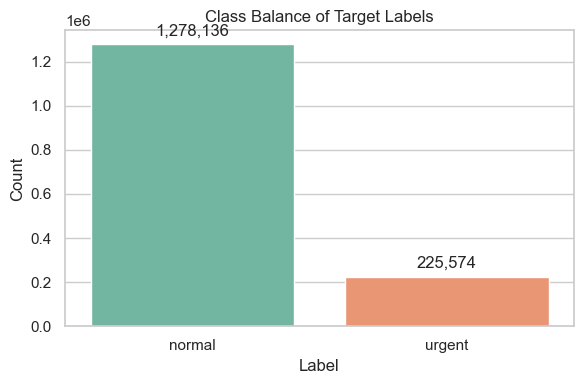

In [55]:
# Chart the class balance of the target labels.
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=class_balance, x="label", y="count", hue="label", palette="Set2", legend=False)
ax.set_title("Class Balance of Target Labels")
ax.set_xlabel("Label")
ax.set_ylabel("Count")

for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_height()):,}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()


In [56]:
# Inspect a few urgent examples before splitting.
urgent_examples = filtered_df.loc[
    filtered_df["label"] == "urgent",
    ["tweet_id", "text", "priority_score", "label"]
].sample(min(10, (filtered_df["label"] == "urgent").sum()), random_state=RANDOM_STATE)

urgent_examples.reset_index(drop=True)


,tweet_id,text,priority_score,label
0,885695,Updated my iPhone and now nothing works! @2531 I canâ€™t send pics or videos. Any suggestions? @115858 this affects my job! #MistressKora,3,urgent
1,1612360,@Safaricom_Care its not working wat next.,2,urgent
2,2120127,@VirginTrains - melting on the 11.40 Glasgow-Euston train as the computer is â€˜brokenâ€™ &amp; heating canâ€™t be adjusted! ðŸ˜–ðŸ˜“,2,urgent
3,77912,@AmericanAir so are you able to cancel my flight full refund now!? i need to book with another airline and can't take any chances. It's going to be harder for customers to book the closer it gets to holiday travel.,7,urgent
4,781759,@ATVIAssist @306635 Is anyone still getting error 5 code cause Iâ€™m still getting it plz help a give me any suggestions,2,urgent
5,588108,@AppleSupport Restarting managed to work on the third attempt. I'm now having an issue syncing the device to my MacBook Pro via iTunes to manually back up,2,urgent
6,2202036,@ATVIAssist my zombie mods are not working is this a glitch or am i doing something wrong Cod ww2,2,urgent
7,828437,@AmericanAir Boarded now but thatâ€™s not the point.,2,urgent
8,1776875,@AppleSupport are the servers down? No iPhone will update today https://t.co/AdYmKpdQHN,2,urgent
9,1737393,@AskPayPal Iâ€™m attempting to check out and when I select login I get an error and this link. https://t.co/o6FwSK5KSS. Please help!!!,3,urgent


In [57]:
# Inspect a few normal examples before splitting.
normal_examples = filtered_df.loc[
    filtered_df["label"] == "normal",
    ["tweet_id", "text", "priority_score", "label"]
].sample(min(10, (filtered_df["label"] == "normal").sum()), random_state=RANDOM_STATE)

normal_examples.reset_index(drop=True)


,tweet_id,text,priority_score,label
0,2091421,@TwitterSupport I need help,0,normal
1,446744,@LondonMidland @123241 No group save option on station ticket machine,0,normal
2,1780814,Hey @115817 thanks for losing my package I dearly need...,-2,normal
3,2273054,@AldiUK Hiya. Gutted. Had to use a whole bag just to make one lot of 'chips for one!' ðŸ˜£ https://t.co/0NLu4oaFZK,0,normal
4,1616781,Vamos @116875 ya cÃ³brame ese Xbox one X para que me llegue el dÃ­a 7 a las 7am.,0,normal
5,1119754,@SpotifyCares Thank you ðŸ˜Š,-2,normal
6,1615920,@115722 This is what Fios gets me and many visits from techs? 30 seconds in on demand and it unwatchable. This is unsatisfactory. #verizonfail https://t.co/UciCfXUYvN,0,normal
7,2340635,@VMUcare @124441 https://t.co/8KIvPYcr5b,0,normal
8,626598,@118919 got my watch delivered but open box without charger and was already used https://t.co/8fDuuxXGfC,0,normal
9,1555883,@ATVIAssist Xbox servers down? https://t.co/jc9xNskzbX,0,normal


In [58]:
X = filtered_df[["text", "clean_text"]]
y = filtered_df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

X_train_raw = X_train["text"].reset_index(drop=True)
X_val_raw = X_val["text"].reset_index(drop=True)
X_test_raw = X_test["text"].reset_index(drop=True)

X_train = X_train["clean_text"].reset_index(drop=True)
X_val = X_val["clean_text"].reset_index(drop=True)
X_test = X_test["clean_text"].reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "urgent_rate": [
        (y_train == "urgent").mean(),
        (y_val == "urgent").mean(),
        (y_test == "urgent").mean(),
    ],
}).assign(urgent_rate=lambda df: df["urgent_rate"].round(4))

print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print("X_train shape:", X_train.shape, "| y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape, "| y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape, "| y_test shape:", y_test.shape)

split_summary


Features shape: (1503710, 2)
Labels shape: (1503710,)
X_train shape: (1052597,) | y_train shape: (1052597,)
X_val shape: (225556,) | y_val shape: (225556,)
X_test shape: (225557,) | y_test shape: (225557,)


,split,rows,urgent_rate
0,train,1052597,0.15
1,validation,225556,0.15
2,test,225557,0.15


In [61]:
def extract_features(text):
    text = normalize_text(text)
    t = text.lower()
    letters = [c for c in text if c.isalpha()]
    upper_ratio = sum(c.isupper() for c in letters) / max(1, len(letters))

    return {
        "length": len(text),
        "word_count": len(text.split()),
        "exclamations": text.count("!"),
        "questions": text.count("?"),
        "uppercase_ratio": upper_ratio,
        "has_refund": int("refund" in t),
        "has_help": int("help" in t),
        "has_error": int("error" in t),
        "has_not_working": int("not working" in t),
        "has_issue": int("issue" in t),
        "has_problem": int("problem" in t),
        "has_delay": int("delay" in t or "delayed" in t),
        "has_waiting": int("waiting" in t),
        "has_login": int("login" in t or "log in" in t),
        "has_charge": int("charged" in t or "charge" in t),
        "has_cancel": int("cancel" in t),
        "has_delivery": int("delivery" in t),
        "has_still": int("still" in t),
        "has_again": int("again" in t),
    }

def build_feature_frame(text_series):
    return text_series.apply(extract_features).apply(pd.Series).fillna(0)


In [62]:
X_train_features = build_feature_frame(X_train)
X_val_features = build_feature_frame(X_val)
X_test_features = build_feature_frame(X_test)

X_train_enriched = pd.concat([X_train_raw.rename("raw_text"), X_train.rename("clean_text"), X_train_features], axis=1)
X_val_enriched = pd.concat([X_val_raw.rename("raw_text"), X_val.rename("clean_text"), X_val_features], axis=1)
X_test_enriched = pd.concat([X_test_raw.rename("raw_text"), X_test.rename("clean_text"), X_test_features], axis=1)

print("X_train_enriched shape:", X_train_enriched.shape)
print("X_val_enriched shape:", X_val_enriched.shape)
print("X_test_enriched shape:", X_test_enriched.shape)

X_train_enriched.head()


X_train_enriched shape: (1052597, 21)
X_val_enriched shape: (225556, 21)
X_test_enriched shape: (225557, 21)


,raw_text,clean_text,length,word_count,exclamations,questions,uppercase_ratio,has_refund,has_help,has_error,...,has_issue,has_problem,has_delay,has_waiting,has_login,has_charge,has_cancel,has_delivery,has_still,has_again
0,@sprintcare I would like to take international calling off my phone plan. Thank you!,I would like to take international calling off my phone plan. Thank you!,72.0,13.0,1.0,0.0,0.034483,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,@314527 Please connect to the router via an Ethernet connection and test at https://t.co/jHAFOc9vGf. \n^BAB,Please connect to the router via an Ethernet connection and test at https://t.co/jHAFOc9vGf. ^BAB,97.0,14.0,0.0,0.0,0.131579,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"@comcastcares I wouldn't call this recent: https://t.co/0ixmuXF9lC\n\nThree different techs couldn't fix it. After that, your phone reps just said I needed to pay for the 75mbps plan. If you couldn't deliver 25, why should I pay for 75? Poor QOS, poor techs, and upselling are why I use AT&amp;T now.","I wouldn't call this recent: https://t.co/0ixmuXF9lC Three different techs couldn't fix it. After that, your phone reps just said I needed to pay for the 75mbps plan. If you couldn't deliver 25, why should I pay for 75? Poor QOS, poor techs, and upselling are why I use AT&amp;T now.",283.0,50.0,0.0,1.0,0.082126,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,@AmazonHelp Your mail is nowhere related to my complaint. Give a proper response!,Your mail is nowhere related to my complaint. Give a proper response!,69.0,12.0,1.0,0.0,0.035714,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,@AmericanAir Problems with food. Problems with baggage. Problems with timing &amp; delays. Please improve your service! Isnâ€™t â€œgreatâ€ what youâ€™re going for!?,Problems with food. Problems with baggage. Problems with timing &amp; delays. Please improve your service! Isnâ€™t â€œgreatâ€ what youâ€™re going for!?,144.0,21.0,2.0,1.0,0.044643,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [63]:
X_train_features.head()


,length,word_count,exclamations,questions,uppercase_ratio,has_refund,has_help,has_error,has_not_working,has_issue,has_problem,has_delay,has_waiting,has_login,has_charge,has_cancel,has_delivery,has_still,has_again
0,72.0,13.0,1.0,0.0,0.034483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,97.0,14.0,0.0,0.0,0.131579,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,283.0,50.0,0.0,1.0,0.082126,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,69.0,12.0,1.0,0.0,0.035714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,144.0,21.0,2.0,1.0,0.044643,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [64]:
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier


In [65]:
numeric_features = X_train_features.columns.tolist()

In [66]:
numeric_transformer = Pipeline(steps =[('imputer', SimpleImputer(strategy='median')),
                                         ('scaler', StandardScaler())
                                         ])

In [67]:
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features)], remainder='drop')

In [68]:
pipe_lr = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
                          ])
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', RandomForestClassifier(n_estimators=100, 
                                                           max_depth=10, 
                                                           class_weight='balanced', 
                                                           n_jobs=-1,
                                                           random_state=42))
                          ])
pipe_xgb = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
))
                           ])

In [69]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

def plot_confusion(model_name, split_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} - {split_name} Confusion Matrix")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

def evaluate_pipeline(model, X_data, y_true, split_name, show_report=True, show_confusion=True):
    y_pred = model.predict(X_data)
    model_name = model.named_steps["model"].__class__.__name__
    metrics = {
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    print(f"{split_name} Accuracy: {metrics['accuracy']:.4f}")
    print(f"{split_name} Weighted F1: {metrics['weighted_f1']:.4f}")

    if show_report:
        print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

    if show_confusion:
        plot_confusion(model_name, split_name, y_true, y_pred)

    return metrics, y_pred


Logistic Regression - Train
Train Accuracy: 0.7824
Train Weighted F1: 0.8004
              precision    recall  f1-score   support

      normal       0.91      0.82      0.87    894695
      urgent       0.36      0.55      0.43    157902

    accuracy                           0.78   1052597
   macro avg       0.63      0.69      0.65   1052597
weighted avg       0.83      0.78      0.80   1052597



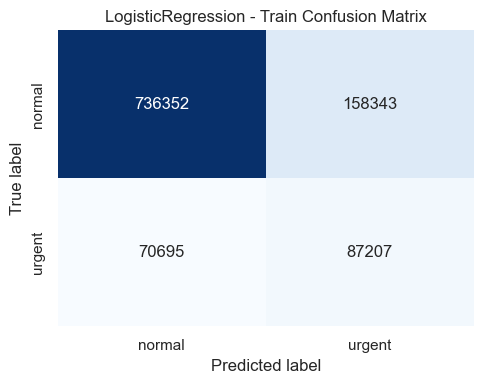

Logistic Regression - Validation
Validation Accuracy: 0.7818
Validation Weighted F1: 0.7998
              precision    recall  f1-score   support

      normal       0.91      0.82      0.87    191720
      urgent       0.35      0.55      0.43     33836

    accuracy                           0.78    225556
   macro avg       0.63      0.69      0.65    225556
weighted avg       0.83      0.78      0.80    225556



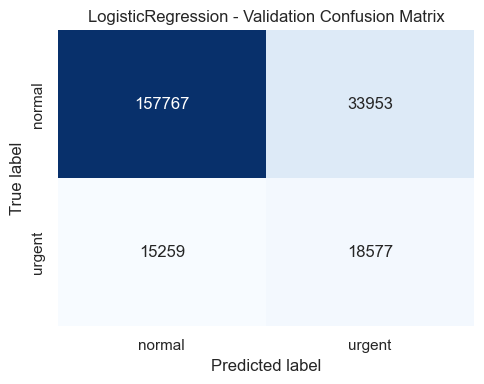

In [70]:
trained_models = {}
model_results = []

pipe_lr.fit(X_train_features, y_train_enc)
trained_models["Logistic Regression"] = pipe_lr

print("Logistic Regression - Train")
lr_train_metrics, _ = evaluate_pipeline(pipe_lr, X_train_features, y_train_enc, "Train")

print("Logistic Regression - Validation")
lr_val_metrics, _ = evaluate_pipeline(pipe_lr, X_val_features, y_val_enc, "Validation")

model_results.append({
    "model": "Logistic Regression",
    "train_accuracy": lr_train_metrics["accuracy"],
    "train_weighted_f1": lr_train_metrics["weighted_f1"],
    "validation_accuracy": lr_val_metrics["accuracy"],
    "validation_weighted_f1": lr_val_metrics["weighted_f1"],
})


Random Forest - Train
Train Accuracy: 0.7906
Train Weighted F1: 0.8064
              precision    recall  f1-score   support

      normal       0.91      0.83      0.87    894695
      urgent       0.37      0.55      0.44    157902

    accuracy                           0.79   1052597
   macro avg       0.64      0.69      0.65   1052597
weighted avg       0.83      0.79      0.81   1052597



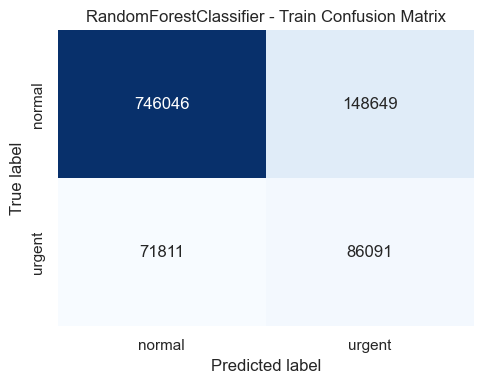

Random Forest - Validation
Validation Accuracy: 0.7895
Validation Weighted F1: 0.8054
              precision    recall  f1-score   support

      normal       0.91      0.83      0.87    191720
      urgent       0.36      0.54      0.44     33836

    accuracy                           0.79    225556
   macro avg       0.64      0.69      0.65    225556
weighted avg       0.83      0.79      0.81    225556



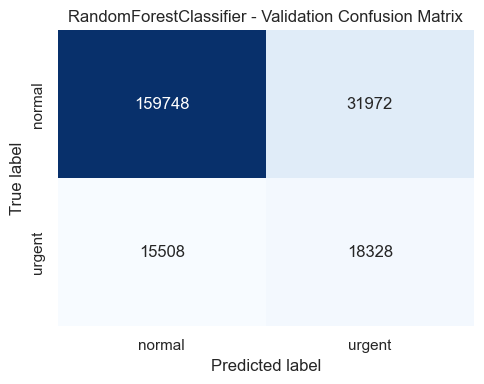

In [71]:
pipe_rf.fit(X_train_features, y_train_enc)
trained_models["Random Forest"] = pipe_rf

print("Random Forest - Train")
rf_train_metrics, _ = evaluate_pipeline(pipe_rf, X_train_features, y_train_enc, "Train")

print("Random Forest - Validation")
rf_val_metrics, _ = evaluate_pipeline(pipe_rf, X_val_features, y_val_enc, "Validation")

model_results.append({
    "model": "Random Forest",
    "train_accuracy": rf_train_metrics["accuracy"],
    "train_weighted_f1": rf_train_metrics["weighted_f1"],
    "validation_accuracy": rf_val_metrics["accuracy"],
    "validation_weighted_f1": rf_val_metrics["weighted_f1"],
})


XGBoost - Train
Train Accuracy: 0.8824
Train Weighted F1: 0.8555
              precision    recall  f1-score   support

      normal       0.88      0.99      0.93    894695
      urgent       0.84      0.27      0.41    157902

    accuracy                           0.88   1052597
   macro avg       0.86      0.63      0.67   1052597
weighted avg       0.88      0.88      0.86   1052597



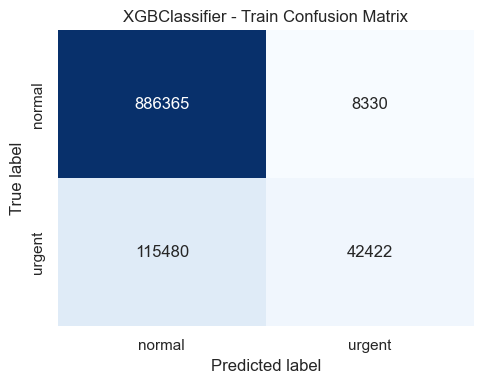

XGBoost - Validation
Validation Accuracy: 0.8824
Validation Weighted F1: 0.8553
              precision    recall  f1-score   support

      normal       0.88      0.99      0.93    191720
      urgent       0.84      0.27      0.40     33836

    accuracy                           0.88    225556
   macro avg       0.86      0.63      0.67    225556
weighted avg       0.88      0.88      0.86    225556



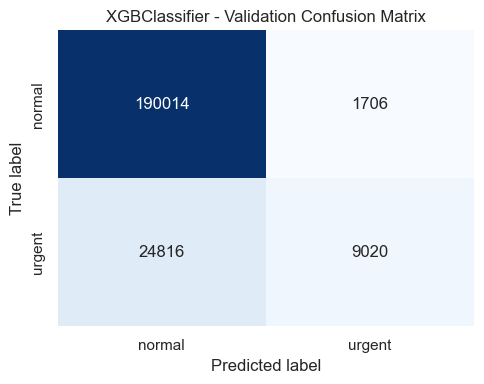

In [72]:
pipe_xgb.fit(X_train_features, y_train_enc)
trained_models["XGBoost"] = pipe_xgb

print("XGBoost - Train")
xgb_train_metrics, _ = evaluate_pipeline(pipe_xgb, X_train_features, y_train_enc, "Train")

print("XGBoost - Validation")
xgb_val_metrics, _ = evaluate_pipeline(pipe_xgb, X_val_features, y_val_enc, "Validation")

model_results.append({
    "model": "XGBoost",
    "train_accuracy": xgb_train_metrics["accuracy"],
    "train_weighted_f1": xgb_train_metrics["weighted_f1"],
    "validation_accuracy": xgb_val_metrics["accuracy"],
    "validation_weighted_f1": xgb_val_metrics["weighted_f1"],
})


In [73]:
from pathlib import Path

comparison_df = (
    pd.DataFrame(model_results)
    .sort_values(["validation_weighted_f1", "validation_accuracy", "train_weighted_f1"], ascending=False)
    .reset_index(drop=True)
)

project_root = Path.cwd()
if project_root.name == "notebook":
    project_root = project_root.parent

model_dir = project_root / "model"
model_dir.mkdir(parents=True, exist_ok=True)

# Keep Logistic Regression as the deployment baseline for this assignment notebook.
best_model_name = "Logistic Regression"
best_model = trained_models[best_model_name]
best_model_path = model_dir / "best_logistic_regression.joblib"
joblib.dump(best_model, best_model_path)

print(f"Selected deployment baseline: {best_model_name}")
print(f"Saved model to: {best_model_path.resolve()}")

comparison_df.round(4)


Selected deployment baseline: Logistic Regression
Saved model to: C:\Users\Kayan\OneDrive\Desktop\SE Factory\week3_project\model\best_logistic_regression.joblib


,model,train_accuracy,train_weighted_f1,validation_accuracy,validation_weighted_f1
0,XGBoost,0.8824,0.8555,0.8824,0.8553
1,Random Forest,0.7906,0.8064,0.7895,0.8054
2,Logistic Regression,0.7824,0.8004,0.7818,0.7998


Test Accuracy: 0.7817
Test Weighted F1: 0.7998
              precision    recall  f1-score   support

      normal       0.91      0.82      0.87    191721
      urgent       0.35      0.55      0.43     33836

    accuracy                           0.78    225557
   macro avg       0.63      0.69      0.65    225557
weighted avg       0.83      0.78      0.80    225557



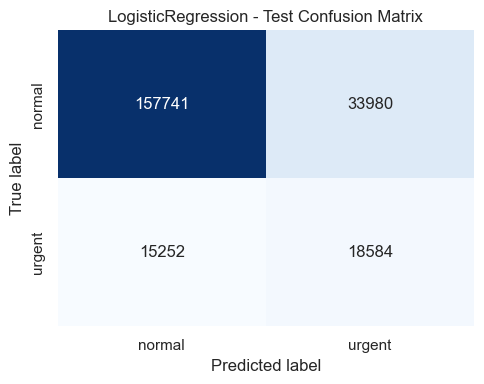

Loaded model from: C:\Users\Kayan\OneDrive\Desktop\SE Factory\week3_project\model\best_logistic_regression.joblib


,model,test_accuracy,test_weighted_f1,n_test_rows
0,Logistic Regression,0.7817,0.7998,225557


,raw_text,clean_text,actual,predicted
0,@Uber_Support my friend left her phone in uber car today https://t.co/gv1cUQY6Dh she is not able to contact uber.,my friend left her phone in uber car today https://t.co/gv1cUQY6Dh she is not able to contact uber.,urgent,normal
1,Dear @idea_cares why r u sending mails on __email__. while I don't have any idea connection. Correct your mistake urgently.,Dear why r u sending mails on __email__. while I don't have any idea connection. Correct your mistake urgently.,normal,normal
2,"@AppleSupport please help - since new update my phone is running slow, blue tooth &amp; touch screen not working well and battery drains. #apple","please help - since new update my phone is running slow, blue tooth &amp; touch screen not working well and battery drains. #apple",urgent,urgent
3,@TMobileHelp @115913 No sorry to basic of an answer i don't need details i ask you to give me a better answer and you failed do do so please stop bothering me,No sorry to basic of an answer i don't need details i ask you to give me a better answer and you failed do do so please stop bothering me,urgent,urgent
4,@AmazonHelp Hi the original date was the 23rd,Hi the original date was the 23rd,normal,normal
5,"@VirginTrains There was no option to reserve when I booked about a week ago, or I would have.","There was no option to reserve when I booked about a week ago, or I would have.",normal,normal
6,"@AppleSupport MY MESSAGES KEEP GLITCHINg, disappearing, imessage keeps coming on and off IM SO FRUSTRATED","MY MESSAGES KEEP GLITCHINg, disappearing, imessage keeps coming on and off IM SO FRUSTRATED",normal,normal
7,What the hell @115940 I was thinking of upgrading my membership but is not even working tonight. What bullshit.,What the hell I was thinking of upgrading my membership but is not even working tonight. What bullshit.,normal,normal
8,@VirginTrains - ticket showing in my app this morning for Euston-Crewe at 10:40am today. Itâ€™s not my booking..??!!ðŸ¤” Please advise.,- ticket showing in my app this morning for Euston-Crewe at 10:40am today. Itâ€™s not my booking..??!!ðŸ¤” Please advise.,urgent,normal
9,"@SpotifyCares Doesn't help at all really.\nI want to create a playlist from ""artistX"" but can only do it from their personal profile, not artist page","Doesn't help at all really. I want to create a playlist from ""artistX"" but can only do it from their personal profile, not artist page",normal,normal


In [74]:
loaded_lr_model = joblib.load(best_model_path)

test_metrics, y_test_pred_enc = evaluate_pipeline(
    loaded_lr_model,
    X_test_features,
    y_test_enc,
    "Test",
)

y_test_pred = label_encoder.inverse_transform(y_test_pred_enc)

test_summary = pd.DataFrame([
    {
        "model": best_model_name,
        "test_accuracy": round(test_metrics["accuracy"], 4),
        "test_weighted_f1": round(test_metrics["weighted_f1"], 4),
        "n_test_rows": len(y_test_pred),
    }
])

test_predictions = pd.DataFrame({
    "raw_text": X_test_raw.reset_index(drop=True),
    "clean_text": X_test.reset_index(drop=True),
    "actual": y_test.reset_index(drop=True),
    "predicted": y_test_pred,
})

print(f"Loaded model from: {best_model_path.resolve()}")
display(test_summary)
test_predictions.head(10)


## RAG Preparation

Create the retrieval dataset, keep only reply-backed support cases, and build a semantic retrieval baseline with Gemini embeddings.


In [98]:
retrieval_dir = project_root / "dataset" / "retrieval"
retrieval_dir.mkdir(parents=True, exist_ok=True)

rag_records_path = retrieval_dir / "support_tickets_for_rag.csv"
rag_records_jsonl_path = retrieval_dir / "support_tickets_for_rag.jsonl"

# Keep the semantic-embedding corpus small enough to batch through an external API.
RETRIEVAL_MAX_ROWS = 1_000
RETRIEVAL_MIN_CHARS = 25
RETRIEVAL_MIN_TOKENS = 4

support_reply_lookup = (
    df.loc[df["inbound"] == False, ["tweet_id", "text"]]
    .dropna(subset=["tweet_id", "text"])
    .assign(
        tweet_id=lambda data: data["tweet_id"].astype(str),
        company_reply_text=lambda data: data["text"],
        company_reply_clean_text=lambda data: data["text"].apply(normalize_text),
    )
    .set_index("tweet_id")
)

def extract_linked_tweet_ids(value):
    if pd.isna(value):
        return []
    return re.findall(r"\d+", str(value))

def join_reply_text(tweet_ids, column_name):
    reply_chunks = []
    for tweet_id in tweet_ids:
        if tweet_id in support_reply_lookup.index:
            reply_chunks.append(str(support_reply_lookup.loc[tweet_id, column_name]))
    return " ".join(chunk for chunk in reply_chunks if chunk).strip()

def build_retrieval_chunk(customer_text, company_reply_text):
    if isinstance(company_reply_text, str) and company_reply_text.strip():
        return f"Customer ticket: {customer_text}\nSupport reply: {company_reply_text}"
    return f"Customer ticket: {customer_text}"

inbound_reply_lookup = (
    df.loc[df["inbound"] == True, ["tweet_id", "response_tweet_id"]]
    .dropna(subset=["tweet_id"])
    .assign(tweet_id=lambda data: data["tweet_id"].astype(str))
    .drop_duplicates(subset="tweet_id")
)

base_retrieval_df = filtered_df[["tweet_id", "text", "clean_text", "priority_score", "label"]].copy()
base_retrieval_df["tweet_id"] = base_retrieval_df["tweet_id"].astype(str)
base_retrieval_df = base_retrieval_df.merge(inbound_reply_lookup, on="tweet_id", how="left")
base_retrieval_df["reply_tweet_ids"] = base_retrieval_df["response_tweet_id"].apply(extract_linked_tweet_ids)
base_retrieval_df["company_reply_text"] = base_retrieval_df["reply_tweet_ids"].apply(
    lambda ids: join_reply_text(ids, "company_reply_text")
)
base_retrieval_df["company_reply_clean_text"] = base_retrieval_df["reply_tweet_ids"].apply(
    lambda ids: join_reply_text(ids, "company_reply_clean_text")
)
base_retrieval_df["retrieval_text"] = base_retrieval_df.apply(
    lambda row: build_retrieval_chunk(row["text"], row["company_reply_text"]),
    axis=1,
)
base_retrieval_df["retrieval_clean_text"] = base_retrieval_df.apply(
    lambda row: build_retrieval_chunk(row["clean_text"], row["company_reply_clean_text"]),
    axis=1,
)
base_retrieval_df["has_company_reply"] = base_retrieval_df["company_reply_clean_text"].str.len().fillna(0).gt(0)
base_retrieval_df["text_length"] = base_retrieval_df["retrieval_clean_text"].str.len()
base_retrieval_df["token_count"] = base_retrieval_df["retrieval_clean_text"].str.split().str.len()

retrieval_df = (
    base_retrieval_df
    .loc[
        lambda data: data["has_company_reply"]
        & (data["text_length"] >= RETRIEVAL_MIN_CHARS)
        & (data["token_count"] >= RETRIEVAL_MIN_TOKENS)
    ]
    .drop_duplicates(subset="retrieval_clean_text")
    .reset_index(drop=True)
)

candidate_count = len(retrieval_df)

if candidate_count > RETRIEVAL_MAX_ROWS:
    retrieval_df, _ = train_test_split(
        retrieval_df,
        train_size=RETRIEVAL_MAX_ROWS,
        random_state=RANDOM_STATE,
        stratify=retrieval_df["label"],
    )
    retrieval_df = retrieval_df.sort_values("tweet_id").reset_index(drop=True)

retrieval_df["doc_id"] = retrieval_df.index.map(lambda idx: f"ticket-{idx:07d}")

retrieval_df = retrieval_df[[
    "doc_id",
    "tweet_id",
    "text",
    "clean_text",
    "company_reply_text",
    "company_reply_clean_text",
    "retrieval_text",
    "retrieval_clean_text",
    "has_company_reply",
    "priority_score",
    "label",
    "text_length",
    "token_count",
]]

retrieval_df.to_csv(rag_records_path, index=False)
retrieval_df.to_json(rag_records_jsonl_path, orient="records", lines=True, force_ascii=False)

print(f"Initial retrieval candidates: {len(base_retrieval_df):,}")
print(f"After reply filter + quality filter + dedupe: {candidate_count:,}")
print(f"Final retrieval rows used for semantic embeddings: {len(retrieval_df):,}")
print(f"Rows with linked company reply: {int(retrieval_df['has_company_reply'].sum()):,}")
print(f"Saved retrieval records to: {rag_records_path.resolve()}")
print(f"Saved retrieval JSONL to: {rag_records_jsonl_path.resolve()}")

retrieval_df.head()


Initial retrieval candidates: 1,503,710
After reply filter + quality filter + dedupe: 1,144,664
Final retrieval rows used for semantic embeddings: 1,000
Rows with linked company reply: 1,000
Saved retrieval records to: C:\Users\Kayan\OneDrive\Desktop\SE Factory\week3_project\dataset\retrieval\support_tickets_for_rag.csv
Saved retrieval JSONL to: C:\Users\Kayan\OneDrive\Desktop\SE Factory\week3_project\dataset\retrieval\support_tickets_for_rag.jsonl


,doc_id,tweet_id,text,clean_text,company_reply_text,company_reply_clean_text,retrieval_text,retrieval_clean_text,has_company_reply,priority_score,label,text_length,token_count
0,ticket-0000000,1001592,@GWRHelp any idea what's happening with 2O94 to yeovil pen mill. Been sat at Bristol for 20 mins?,any idea what's happening with 2O94 to yeovil pen mill. Been sat at Bristol for 20 mins?,"@146836 I am sorry for the late departure, James. This was due to train crew being delayed on another service. - Jordan","I am sorry for the late departure, James. This was due to train crew being delayed on another service. - Jordan","Customer ticket: @GWRHelp any idea what's happening with 2O94 to yeovil pen mill. Been sat at Bristol for 20 mins?\nSupport reply: @146836 I am sorry for the late departure, James. This was due to train crew being delayed on another service. - Jordan","Customer ticket: any idea what's happening with 2O94 to yeovil pen mill. Been sat at Bristol for 20 mins?\nSupport reply: I am sorry for the late departure, James. This was due to train crew being delayed on another service. - Jordan",True,0,normal,232,42
1,ticket-0000001,1002720,Their systems are always outta whack and then I get screwed over financially,Their systems are always outta whack and then I get screwed over financially,@227508 We apologize for the inconvenience. Our systems are now functional. Let us know if you need help with your account. ^PE,We apologize for the inconvenience. Our systems are now functional. Let us know if you need help with your account. ^PE,Customer ticket: Their systems are always outta whack and then I get screwed over financially\nSupport reply: @227508 We apologize for the inconvenience. Our systems are now functional. Let us know if you need help with your account. ^PE,Customer ticket: Their systems are always outta whack and then I get screwed over financially\nSupport reply: We apologize for the inconvenience. Our systems are now functional. Let us know if you need help with your account. ^PE,True,0,normal,228,38
2,ticket-0000002,1007029,"@AmazonHelp It has literally just been dispatched. App now says expected 22-24th. Let's not beat around the bush, it's arriving Tuesday isn't it.","It has literally just been dispatched. App now says expected 22-24th. Let's not beat around the bush, it's arriving Tuesday isn't it.",@358302 Deliveries take place up to 9pm. Any parcel that doesn't arrive by then will be rescheduled for delivery the next business day.^ZW,Deliveries take place up to 9pm. Any parcel that doesn't arrive by then will be rescheduled for delivery the next business day.^ZW,"Customer ticket: @AmazonHelp It has literally just been dispatched. App now says expected 22-24th. Let's not beat around the bush, it's arriving Tuesday isn't it.\nSupport reply: @358302 Deliveries take place up to 9pm. Any parcel that doesn't arrive by then will be rescheduled for delivery the next business day.^ZW","Customer ticket: It has literally just been dispatched. App now says expected 22-24th. Let's not beat around the bush, it's arriving Tuesday isn't it.\nSupport reply: Deliveries take place up to 9pm. Any parcel that doesn't arrive by then will be rescheduled for delivery the next business day.^ZW",True,2,urgent,296,48
3,ticket-0000003,1010991,@115783 your @29992 rating is 1.3 out of 10. You are failing at refunds and customer service.It will only become more obvious in time.,your rating is 1.3 out of 10. You are failing at refunds and customer service.It will only become more obvious in time.,"@190210 Hi Lale, please rest assured our team are looking into it and you'll receive an update shortly. Thank you","Hi Lale, please rest assured our team are looking into it and you'll receive an update shortly. Thank you","Customer ticket: @115783 your @29992 rating is 1.3 out of 10. You are failing at refunds and customer service.It will only become more obvious in time.\nSupport reply: @190210 Hi Lale, please rest assured our team are looking

In [124]:
# Make sure VOYAGE_API_KEY is set in your environment or .env file before running the embedding cell.
import os
from dotenv import load_dotenv

load_dotenv()
print("VOYAGE_API_KEY set:", bool(os.getenv("VOYAGE_API_KEY")))


VOYAGE_API_KEY set: True


In [ ]:
import importlib
import sys

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import voyage_embedding_pipeline

importlib.reload(voyage_embedding_pipeline)
print("Embedding model:", voyage_embedding_pipeline.VOYAGE_EMBEDDING_MODEL)

rag_embeddings_path = model_dir / "rag_voyage_embeddings.npy"
rag_embedding_metadata_path = model_dir / "rag_voyage_embedding_metadata.json"

rag_embeddings, embedding_metadata = voyage_embedding_pipeline.build_voyage_embeddings(
    records_path=rag_records_path,
    embeddings_path=rag_embeddings_path,
    metadata_path=rag_embedding_metadata_path,
    text_column="retrieval_clean_text",
    batch_size=25,
    max_chars=300,
    sleep_seconds=21.0,
    max_retries=5,
)

print(f"Saved Voyage embeddings to: {rag_embeddings_path.resolve()}")
print(f"Saved embedding metadata to: {rag_embedding_metadata_path.resolve()}")
print(f"Embedding matrix shape: {rag_embeddings.shape}")
embedding_metadata


In [128]:
import importlib

import voyage_embedding_pipeline
from sklearn.metrics.pairwise import cosine_similarity

importlib.reload(voyage_embedding_pipeline)

def retrieve_similar_tickets(query, top_k=5):
    query_embedding = voyage_embedding_pipeline.embed_query_text(normalize_text(query))
    similarity_scores = cosine_similarity(query_embedding, rag_embeddings).ravel()
    top_indices = similarity_scores.argsort()[::-1][:top_k]

    results = retrieval_df.iloc[top_indices].copy()
    results["similarity"] = similarity_scores[top_indices]

    return results[[
        "doc_id",
        "tweet_id",
        "text",
        "clean_text",
        "company_reply_text",
        "retrieval_text",
        "label",
        "priority_score",
        "similarity",
    ]].reset_index(drop=True)

sample_query = "I was charged twice and still cannot log in to my account"
retrieve_similar_tickets(sample_query, top_k=5)


,doc_id,tweet_id,text,clean_text,company_reply_text,retrieval_text,label,priority_score,similarity
0,ticket-0000698,2886301,@idea_cares idea is the worst network in fake chareges..,idea is the worst network in fake chareges..,"@572199 We are sorry for the inconvenience caused to you. But as checked the service has been activated from your end only. Hence you have been charged.\n\nRegards,\nArti","Customer ticket: @idea_cares idea is the worst network in fake chareges..\nSupport reply: @572199 We are sorry for the inconvenience caused to you. But as checked the service has been activated from your end only. Hence you have been charged.\n\nRegards,\nArti",normal,1,0.584552
1,ticket-0000099,129976,@Uber_Support @119983 @115873 i have already mailed several times....also i have deleted and re created mt account but nothing works. Ur customer support sucks. Again you are re routing the complaint. It will not produce anything fruitful like this.,i have already mailed several times....also i have deleted and re created mt account but nothing works. Ur customer support sucks. Again you are re routing the complaint. It will not produce anything fruitful like this.,"@145298 Thanks for letting us know, Pulkit. We're taking a closer look, and have identified an issue affecting your ability to use your account. We've reached out with more details on your support conversation. Please follow up with us there so we can further assist.","Customer ticket: @Uber_Support @119983 @115873 i have already mailed several times....also i have deleted and re created mt account but nothing works. Ur customer support sucks. Again you are re routing the complaint. It will not produce anything fruitful like this.\nSupport reply: @145298 Thanks for letting us know, Pulkit. We're taking a closer look, and have identified an issue affecting your ability to use your account. We've reached out with more details on your support conversation. Please follow up with us there so we can further assist.",normal,1,0.572232
2,ticket-0000266,174972,@SpotifyCares Nope. Also deleted and reinstalled,Nope. Also deleted and reinstalled,"@157052 Thanks for keeping us updated. Can you DM us your account's email address or username? Knowing if this is happening while connected to WiFi, 3G/4G or both would also be helpful. \nWe'll check it out 🔍 /LJ https://t.co/ldFdZRiNAt","Customer ticket: @SpotifyCares Nope. Also deleted and reinstalled\nSupport reply: @157052 Thanks for keeping us updated. Can you DM us your account's email address or username? Knowing if this is happening while connected to WiFi, 3G/4G or both would also be helpful. \nWe'll check it out 🔍 /LJ https://t.co/ldFdZRiNAt",normal,0,0.561899
3,ticket-0000410,2158619,"@SpotifyCares I have the student discount for spotify premium and I got charged double this month and my hulu stopped working, what can I do to fix it???","I have the student discount for spotify premium and I got charged double this month and my hulu stopped working, what can I do to fix it???",@634065 Hey there! Can you DM us your account's email address? We'll take a look /RB https://t.co/ldFdZRiNAt,"Customer ticket: @SpotifyCares I have the student discount for spotify premium and I got charged double this month and my hulu stopped working, what can I do to fix it???\nSupport reply: @634065 Hey there! Can you DM us your account's email address? We'll take a look /RB https://t.co/ldFdZRiNAt",urgent,3,0.561657
4,ticket-0000928,810722,"Got iMessage straightened out 😂\n\nAfter all that, it was fine!\n\nThe main problem was my old AT&amp;T account getting hacked online!!!! Won't let","Got iMessage straightened out 😂 After all that, it was fine! The main problem was my old AT&amp;T account getting hacked online!!!! Won't let","@167615 Michelrá, please DM us with your account # and contact info. We'd like to help get to the bottom of this for you. Thank you.","Customer ticket: Got iMessage straightened out 😂\n\nAfter all that, it was fine!\n\nThe main prob

In [129]:
import numpy as np
import pandas as pd

df = pd.read_csv("../dataset/retrieval/support_tickets_for_rag.csv")
emb = np.load("../model/rag_voyage_embeddings.npy")

print(len(df), emb.shape)


1000 (1000, 1024)
